In [21]:
import os

data_dir = "all_audio"

filepaths = [
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.endswith(".wav")
]

print(len(filepaths))  # should be 1440

1440


In [22]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}
intensity_map = {
    "01": "normal",
    "02": "strong"
}

In [23]:
labels = []

for path in filepaths:
    filename = os.path.basename(path)
    emotion_id = filename.split("-")[2]
    labels.append(emotion_map[emotion_id])

labels[:10]

['angry',
 'neutral',
 'surprised',
 'disgust',
 'fearful',
 'sad',
 'surprised',
 'surprised',
 'calm',
 'fearful']

In [24]:
data = list(zip(filepaths, labels))
data[:5]

[('all_audio/03-01-05-02-02-01-17.wav', 'angry'),
 ('all_audio/03-01-01-01-02-01-12.wav', 'neutral'),
 ('all_audio/03-01-08-01-01-02-19.wav', 'surprised'),
 ('all_audio/03-01-07-01-01-02-19.wav', 'disgust'),
 ('all_audio/03-01-06-01-02-02-04.wav', 'fearful')]

In [25]:
import pandas as pd

df = pd.DataFrame(data, columns=["path", "emotion"])
df.head()

,path,emotion
0,all_audio/03-01-05-02-02-01-17.wav,angry
1,all_audio/03-01-01-01-02-01-12.wav,neutral
2,all_audio/03-01-08-01-01-02-19.wav,surprised
3,all_audio/03-01-07-01-01-02-19.wav,disgust
4,all_audio/03-01-06-01-02-02-04.wav,fearful


In [26]:
import os
import pandas as pd

rows = []

for path in filepaths:
    filename = os.path.basename(path)
    parts = filename.replace(".wav", "").split("-")
    
    emotion = parts[2]      # 3rd slot
    intensity = parts[3]    # 4th slot (01=normal, 02=strong)
    actor = parts[6]        # 7th slot
    
    rows.append({
        "path": path,
        "emotion": emotion,
        "intensity": intensity,
        "actor": actor
    })

df = pd.DataFrame(rows)
df.head()

,path,emotion,intensity,actor
0,all_audio/03-01-05-02-02-01-17.wav,05,02,17
1,all_audio/03-01-01-01-02-01-12.wav,01,01,12
2,all_audio/03-01-08-01-01-02-19.wav,08,01,19
3,all_audio/03-01-07-01-01-02-19.wav,07,01,19
4,all_audio/03-01-06-01-02-02-04.wav,06,01,04


In [27]:
df["emotion"] = df["emotion"].map(emotion_map)
df["intensity"] = df["intensity"].map(intensity_map)

df.head()

,path,emotion,intensity,actor
0,all_audio/03-01-05-02-02-01-17.wav,angry,strong,17
1,all_audio/03-01-01-01-02-01-12.wav,neutral,normal,12
2,all_audio/03-01-08-01-01-02-19.wav,surprised,normal,19
3,all_audio/03-01-07-01-01-02-19.wav,disgust,normal,19
4,all_audio/03-01-06-01-02-02-04.wav,fearful,normal,04


In [28]:
df.groupby(["emotion", "intensity"]).size()

emotion    intensity
angry      normal       96
           strong       96
calm       normal       96
           strong       96
disgust    normal       96
           strong       96
fearful    normal       96
           strong       96
happy      normal       96
           strong       96
neutral    normal       96
sad        normal       96
           strong       96
surprised  normal       96
           strong       96
dtype: int64

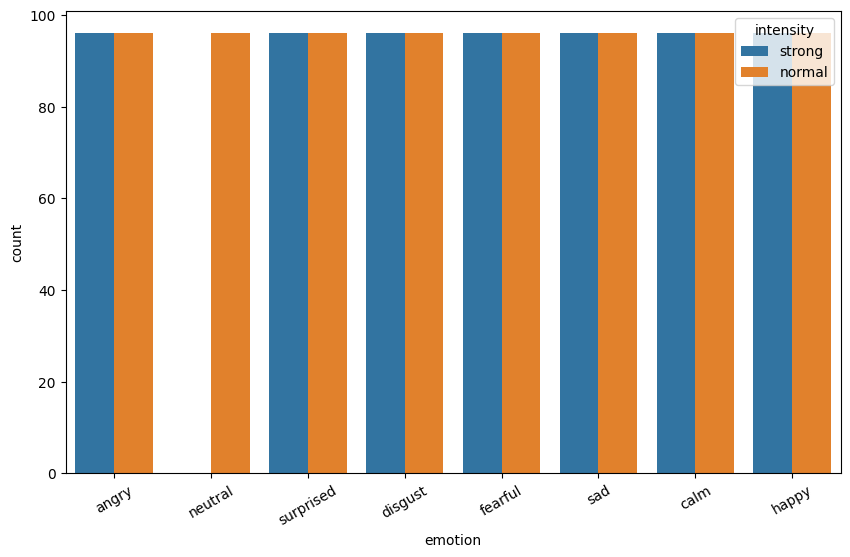

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="emotion", hue="intensity")
plt.xticks(rotation=30)
plt.show()

In [30]:
pivot = df.pivot_table(
    index="emotion",
    columns=["intensity", "actor"],
    aggfunc="size",
    fill_value=0
)
pivot

intensity normal                             ... strong                       \
actor         01 02 03 04 05 06 07 08 09 10  ...     15 16 17 18 19 20 21 22   
emotion                                      ...                               
angry          4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
calm           4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
disgust        4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
fearful        4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
happy          4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
neutral        4  4  4  4  4  4  4  4  4  4  ...      0  0  0  0  0  0  0  0   
sad            4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   
surprised      4  4  4  4  4  4  4  4  4  4  ...      4  4  4  4  4  4  4  4   

intensity        
actor     23 24  
emotion          
angry      4  4  
calm       4  4  
disgust    4  4  
fearful    4  4  
happy      4  4  
neutral    0  0  
sad        4  4  
surprised  4  4  

[8 rows x 48 columns]